In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import norm

In [2]:
class StochasticProcess:
    def __init__(self, params, T, Nx, Nt, init_state = None):
        self.params = params
        self.T = T
        self.Nx = Nx
        self.Nt = Nt
        self.init_state = init_state

        #Wiener Process by default
        self.bxt = lambda x: 0
        self.sigmaxt = lambda x: 1

    def sampler_init_state(self):
        return np.zeros(self.Nx)

    def EulerSolution(self):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        if self.init_state is None:
            x_data[0] = self.sampler_init_state()
        else:
            x_data[0] = self.init_state

        for i in range(1, self.Nt + 1):
            dwt = np.random.normal(0, 1, size = self.Nx) * np.sqrt(dt)
            x_data[i] = x_data[i - 1] + self.bxt(x_data[i - 1]) * dt + self.sigmaxt(x_data[i - 1]) * dwt
        return t_data, x_data

# Примеры

Exercise 1. Use the stochastic integral Ito, $N=1000$ to simulate and plot a path with $X_0 = 10$ of
*   the Ornstein-Uhlenbeck process, $\mathbb{\theta} = (-5.0, 0.0, 3.5)$;
*   the Cox-Ingersoll-Ross process, $\mathbb{\theta} = (2.00, 0.20, 0.15)$;
*   the Black-Scholes-Merton process, $\mathbb{\theta} = (1.0, 0.2)$.


Пример 1. Используя стохастический интеграл Ито, $N=1000$, смоделируйте и постройте траекторию с $X_0 = 10$ для:
* процесса Орнштейна-Уленбека, $\mathbb{\theta} = (-5.0, 0.0, 3.5)$;
* процесса Кокса-Ингерсолла-Росса, $\mathbb{\theta} = (2.00, 0.20, 0.15)$;
* процесса Блэка-Шоулза-Мертона, $\mathbb{\theta} = (1.0, 0.2)$.

In [3]:
class OrnsteinUhlenbeckProcess(StochasticProcess):
    def __init__(self, params, T, Nx, Nt, init_state = None):
        super().__init__(params, T, Nx, Nt, init_state)

        # params = [theta, mu, sigma]
        self.bxt = lambda x: self.params[0] * (self.params[1] - x)
        self.sigmaxt = lambda x: self.params[2]

    def sampler_init_state(self):
        return self.params[1] * np.ones(self.Nx)


class CoxIngersollRossProcess(StochasticProcess):
    def __init__(self, params, T, Nx, Nt, init_state = None):
        super().__init__(params, T, Nx, Nt, init_state)

        # params = [theta1, theta2, theta3]
        self.bxt = lambda x: self.params[0] - self.params[1] * x
        self.sigmaxt = lambda x: self.params[2] * np.sqrt(np.maximum(x, 0))

    def sampler_init_state(self):
        return self.params[0] / self.params[1] * np.ones(self.Nx)


class BlackScholesMertonProcess(StochasticProcess):
    def __init__(self, params, T, Nx, Nt, init_state = None):
        super().__init__(params, T, Nx, Nt, init_state)

        # params = [theta1, theta2]
        self.bxt = lambda x: self.params[0] * x
        self.sigmaxt = lambda x: self.params[1] * x

    def sampler_init_state(self):
        return np.ones(self.Nx)

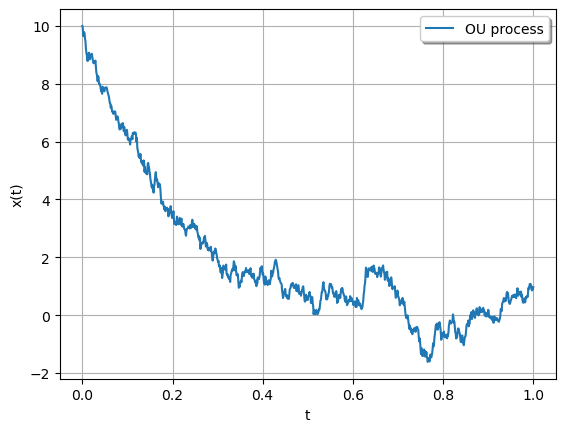

In [4]:
T = 1
Nx = 1
Nt = 1000

init_state = 10 * np.ones(Nx)

theta = 5
mu = 0
sigma = 3.5
params = [theta, mu, sigma]

OUProcess = OrnsteinUhlenbeckProcess(params, T, Nx, Nt, init_state)
t_data, x_data = OUProcess.EulerSolution()
plt.plot(t_data, x_data, label = 'OU process')

plt.legend(loc = 'best', fancybox = True, shadow = True)
plt.xlabel("t")
plt.ylabel("x(t)")
plt.grid(True)
plt.show()

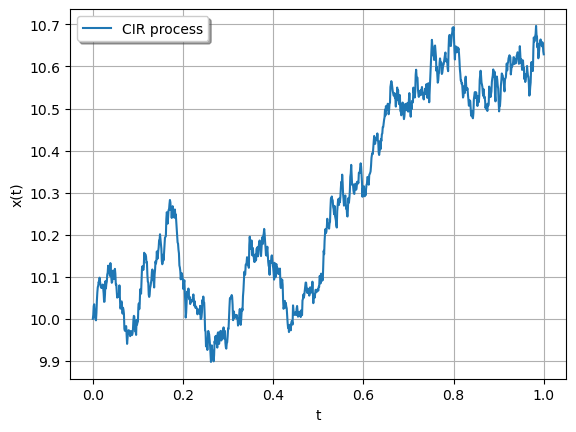

In [5]:
theta1 = 2
theta2 = 0.2
theta3 = 0.15
params = [theta1, theta2, theta3]

CIRProcess = CoxIngersollRossProcess(params, T, Nx, Nt, init_state)
t_data, x_data = CIRProcess.EulerSolution()
plt.plot(t_data, x_data, label = 'CIR process')

plt.legend(loc = 'best', fancybox = True, shadow = True)
plt.xlabel("t")
plt.ylabel("x(t)")
plt.grid(True)
plt.show()

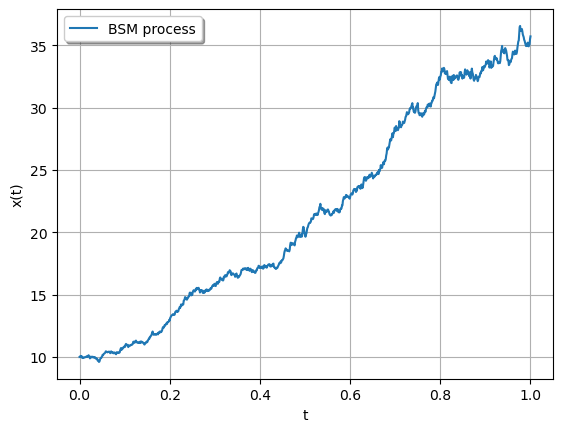

In [6]:
theta1 = 1.0
theta2 = 0.2
params = [theta1, theta2]

BSMProcess = BlackScholesMertonProcess(params, T, Nx, Nt, init_state)
t_data, x_data = BSMProcess.EulerSolution()
plt.plot(t_data, x_data, label = 'BSM process')

plt.legend(loc = 'best', fancybox = True, shadow = True)
plt.xlabel("t")
plt.ylabel("x(t)")
plt.grid(True)
plt.show()

Exercise 2. Compute a confidence interval of the CIR process from the previous task. Plot the paths and a confidence interval.

Пример 2. Вычислите доверительный интервал для процесса CIR из предыдущего примера. Постройте графики траекторий и доверительный интервал.

In [7]:
def zeta(sigma, theta, t, s):
    return sigma**2 / (4 * theta) * (1 - np.exp(-theta * (t - s)))

def CIRbounds(alpha_interval, params, t, s, xs):
    theta1, theta2, theta3 = params[0], params[1], params[2]
    theta = theta2
    beta = theta1 / theta2
    sigma = theta3

    k = 4  / sigma**2 * theta * beta
    lambd = 4 * theta / sigma**2  * np.exp(-theta * (t - s)) / (1 - np.exp(-theta * (t - s))) * xs
    ksi = norm.ppf(1 - alpha_interval / 2)

    b1 = zeta(sigma, theta, t, s) * (k + lambd - ksi * np.sqrt(2 * (k + 2 * lambd)))
    b2 = zeta(sigma, theta, t, s) * (k + lambd + ksi * np.sqrt(2 * (k + 2 * lambd)))
    return [b1, b2]


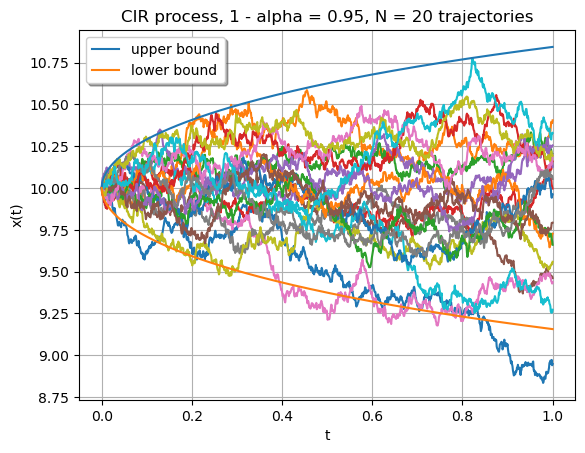

In [8]:
theta1 = 2
theta2 = 0.2
theta3 = 0.15
params = [theta1, theta2, theta3]

Nx = 20

x0 = 10
init_state = x0 * np.ones(Nx)
alpha_interval = 0.05

CIRProcess = CoxIngersollRossProcess(params, T, Nx, Nt, init_state)
t_data, x_data = CIRProcess.EulerSolution()
for k in range(0, Nx):
    plt.plot(t_data, x_data[:,k])

low_bound_data = np.zeros_like(t_data)
up_bound_data = np.zeros_like(t_data)

for i in range(1, len(t_data)):
    bounds = CIRbounds(alpha_interval, params, t_data[i], 0, x0)
    low_bound_data[i] = bounds[0]
    up_bound_data[i] = bounds[1]
low_bound_data[0] = x0
up_bound_data[0] = x0
plt.plot(t_data, up_bound_data, label = f"upper bound")
plt.plot(t_data, low_bound_data, label = f"lower bound")

plt.title(f"CIR process, 1 - alpha = {1-alpha_interval}, N = {Nx} trajectories")
plt.legend(loc = 'best', fancybox = True, shadow = True)
plt.xlabel("t")
plt.ylabel("x(t)")
plt.grid(True)
plt.show()

Exercise 3. For the Ornstein-Uhlenbeck process
$$
dX_t = \theta(\mu - X_t)dt + \sigma dW_t, \quad \theta = 1, \quad \mu = 1.2, \quad \sigma = 0.3
$$
generate three paths: $X_0 = 0.0, 2.0, \mathcal{N}\left(\mu, \frac{\sigma^2}{2\theta}\right)$ and plot in graph.


Пример 3. Для процесса Орштейна-Улумбека
$$
dX_t = \theta(\mu - X_t)dt + \sigma dW_t, \quad \theta = 1, \quad \mu = 1.2, \quad \sigma = 0.3
$$
сгенерируйте три траектории: $X_0 = 0.0, 2.0, \mathcal{N}\left(\mu, \frac{\sigma^2}{2\theta}\right)$ и постройте их на одном графике.


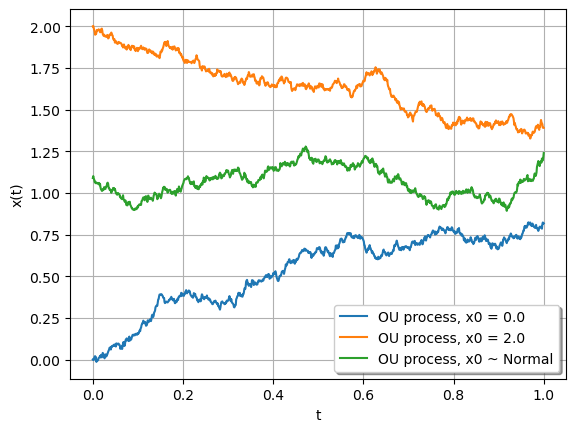

In [9]:
T = 1
Nx = 1
Nt = 1000

theta = 1
mu = 1.2
sigma = 0.3
params = [theta, mu, sigma]

x0 = 0.0
init_state = x0 * np.ones(Nx)
OUProcess = OrnsteinUhlenbeckProcess(params, T, Nx, Nt, init_state)

t_data, x_data = OUProcess.EulerSolution()
plt.plot(t_data, x_data, label = f'OU process, x0 = {x0}')

x0 = 2.0
init_state = x0 * np.ones(Nx)
OUProcess = OrnsteinUhlenbeckProcess(params, T, Nx, Nt, init_state)

t_data, x_data = OUProcess.EulerSolution()
plt.plot(t_data, x_data, label = f'OU process, x0 = {x0}')


init_state = np.random.normal(mu, sigma**2/(2 * theta), size = Nx)
OUProcess = OrnsteinUhlenbeckProcess(params, T, Nx, Nt, init_state)

t_data, x_data = OUProcess.EulerSolution()
plt.plot(t_data, x_data, label = f'OU process, x0 ~ Normal')

plt.legend(loc = 'best', fancybox = True, shadow = True)
plt.xlabel("t")
plt.ylabel("x(t)")
plt.grid(True)
plt.show()

# Exercises

Exercise 1. Define a path with the stationary distribution from the graph and prove mathematically.

In [10]:
# your code for prove

Exercise 2.  Design a process that stays in the interval $[0, 1]$ and mean-reverts around $1/2$, generate paths for different $\theta$ and plot their in graph. Prove your solution.


Hint
$$
\mu(x) = \theta (1/2 - x), \quad \sigma(x) = \sigma \cdot x (1-x).
$$

That is
$$
dx = \theta (1/2 - x )dt + \sigma \cdot x (1-x) dW.
$$
Note: diffusion goes to zero at boundaries $\sigma(0) = \sigma(1) = 0$ and
mean-reverts  $⇒$ always stay in $[0, 1]$.

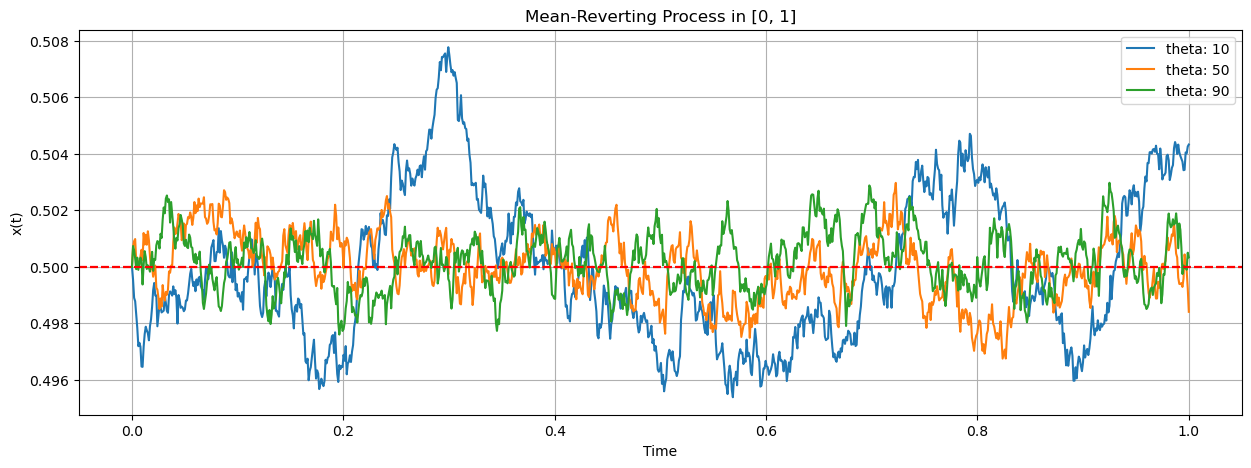

In [11]:
def DesingProcess(theta=0, n=10):
    # Parameters
    T = 1.0        # Total time
    Nt = 1000      # Number of time steps
    # theta = 5.0  # Mean reversion speed
    sigma = 0.05   # Volatility

    # Time discretization
    dt = T / Nt
    t = np.linspace(0, T, Nt)

    # Initial state
    x0 = 0.5  # Starting at the mean
    x_data = np.zeros(Nt)
    x_data[0] = x0


    plt.figure(figsize=(15,5))
    for theta in np.arange(10, 100, 40):
        # Simulating the process
        for i in range(1, Nt):
            x_prev = x_data[i - 1]
            drift = theta * (0.5 - x_prev) * dt
            diffusion = sigma * x_prev * (1 - x_prev) * np.sqrt(dt) * np.random.normal()
            x_data[i] = x_prev + drift + diffusion

        # Plotting the result
        plt.plot(t, x_data, label=f'theta: {theta}')
        plt.axhline(y=0.5, color='r', linestyle='--')
        plt.xlabel('Time')
        plt.ylabel('x(t)')
        plt.title('Mean-Reverting Process in [0, 1]')
        plt.legend()
        plt.grid(True)
    plt.show()

DesingProcess()

Exercise 3. Sove Exercise 2 for common case: interval $[a, b]$ and mean-reverts around  $c$, where $c \sim U(a,b)$.

In [12]:
# your code

Exercise 4. Using the class template from Task 1, create classes and plot graphs for the following processes:

1.   Modified CIR model;
2.   Chan-Karolyi-Longstaff-Sanders family of models;
1.   Nonlinear mean reversion Ait-Sahalia model;
2.   Jacobi diffusion process;
1.   Ahn and Gao (inverse of Feller’s square root) model;
2.   Radial Ornstein-Uhlenbeck process.

Provide examples for illustration the results on graphs.





In [13]:
class ModifiedCIRProcess(StochasticProcess):
    def __init__(self, params, T, Nx, Nt, init_state=None):
        super().__init__(params, T, Nx, Nt, init_state)
        # params = [theta, mu, sigma]
        self.bxt = lambda x: self.params[0] * (self.params[1] - x)
        self.sigmaxt = lambda x: self.params[2] * np.sqrt(np.maximum(x, 0))

    def sampler_init_state(self):
        return np.full(self.Nx, self.params[1])

In [14]:
class CKLSProcess(StochasticProcess):
    def __init__(self, params, T, Nx, Nt, init_state=None):
        super().__init__(params, T, Nx, Nt, init_state)
        # params = [theta, mu, sigma, alpha]
        self.bxt = lambda x: self.params[0] * (self.params[1] - x)
        self.sigmaxt = lambda x: self.params[2] * x ** self.params[3]

    def sampler_init_state(self):
        return np.full(self.Nx, self.params[1])

In [15]:
class AitSahaliaProcess(StochasticProcess):
    def __init__(self, params, T, Nx, Nt, init_state=None):
        super().__init__(params, T, Nx, Nt, init_state)
        # params = [theta, mu, sigma]
        self.bxt = lambda x: self.params[0] * (self.params[1] - x ** 2)
        self.sigmaxt = lambda x: self.params[2]

    def sampler_init_state(self):
        return np.full(self.Nx, self.params[1] ** 0.5)

In [16]:
class JacobiProcess(StochasticProcess):
    def __init__(self, params, T, Nx, Nt, init_state=None):
        super().__init__(params, T, Nx, Nt, init_state)
        # params = [theta, mu, sigma]
        self.bxt = lambda x: self.params[0] * (self.params[1] - x)
        self.sigmaxt = lambda x: self.params[2] * (1 - x) * (1 + x)

    def sampler_init_state(self):
        return np.full(self.Nx, self.params[1])

In [17]:
class AhnGaoProcess(StochasticProcess):
    def __init__(self, params, T, Nx, Nt, init_state=None):
        super().__init__(params, T, Nx, Nt, init_state)
        # params = [theta, mu, sigma]
        self.bxt = lambda x: self.params[0] * (self.params[1] - x)
        self.sigmaxt = lambda x: self.params[2] * np.sqrt(np.maximum(x, 0))

    def sampler_init_state(self):
        return np.full(self.Nx, self.params[1])

In [18]:
class RadialOUProcess(StochasticProcess):
    def __init__(self, params, T, Nx, Nt, init_state=None):
        super().__init__(params, T, Nx, Nt, init_state)
        # params = [theta, sigma]
        self.bxt = lambda x: -self.params[0] * x
        self.sigmaxt = lambda x: self.params[1]

    def sampler_init_state(self):
        return np.zeros(self.Nx)  # Starting at the origin

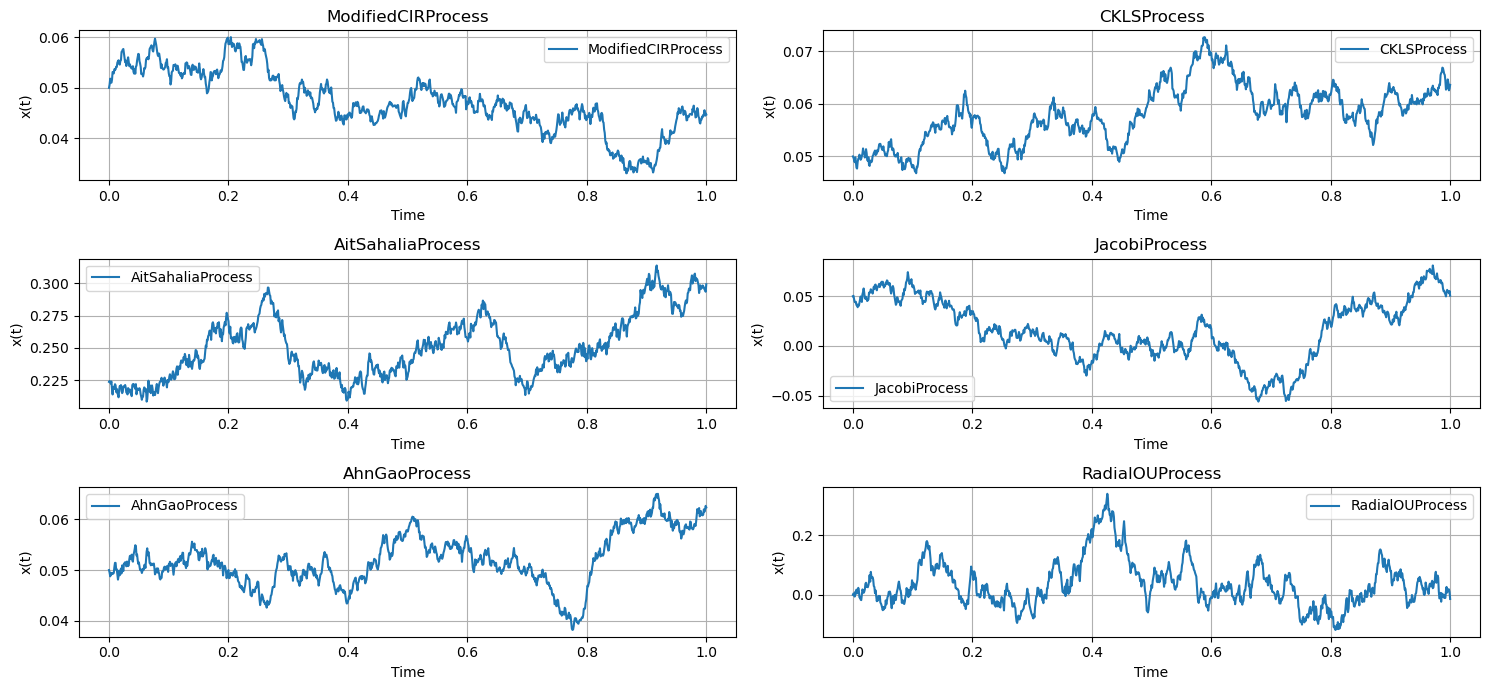

In [19]:
# Common parameters for the models
T = 1.0
Nx = 1
Nt = 1000

# Parameters for each model
params_cir = [0.1, 0.05, 0.1]  # Modified CIR
params_ckls = [0.1, 0.05, 0.1, 0.5]  # CKLS
params_ait = [0.1, 0.05, 0.1]  # Ait-Sahalia
params_jacobi = [0.1, 0.05, 0.1]  # Jacobi
params_ahn = [0.1, 0.05, 0.1]  # Ahn and Gao
params_radial_ou = [15, 0.5]  # Radial OU

# Create instances of each process
processes = [
    ModifiedCIRProcess(params_cir, T, Nx, Nt),
    CKLSProcess(params_ckls, T, Nx, Nt),
    AitSahaliaProcess(params_ait, T, Nx, Nt),
    JacobiProcess(params_jacobi, T, Nx, Nt),
    AhnGaoProcess(params_ahn, T, Nx, Nt),
    RadialOUProcess(params_radial_ou, T, Nx, Nt)
]

# Plotting each process
plt.figure(figsize=(15, 7))

for i, process in enumerate(processes):
    t_data, x_data = process.EulerSolution()
    plt.subplot(3, 2, i + 1)
    plt.plot(t_data, x_data, label=process.__class__.__name__)
    plt.title(process.__class__.__name__)
    plt.xlabel('Time')
    plt.ylabel('x(t)')
    plt.grid()
    plt.legend()

plt.tight_layout()
plt.show()

Exercise 5.

Let $$X(t)=e^{-\kappa t} X_0 + \theta (1-e^{-\kappa t}) + \sigma e^{-\kappa t} \int_0^t e^{\kappa s}\sqrt{X(t)}dW(s)$$ be extract solution for CIR model.


 Expand the functionality of the class CoxIngersollRossProcess(StochasticProcess) and compute the first and second moments of the extract solution $\mathbb{E}\{X^n(t)\}$ using the general formula [Jafari, 2017]
$$
\mathbb{E}\{X^n(t)\} = \sum_{j=0}^{[n/2]}A^{n-2j}(t)B^{2j}(t)
\left(\frac{1}{2\kappa}(e^{2\kappa t} - 1)\right)^{2j}, \quad \forall n \in \mathbb{N},
$$
where $A(t)=e^{-\kappa t X_0} + \theta(1-e^{-\kappa t})$,
$B(t)=\sigma e^{-\kappa t}$, $[n/2]$ denotes the greatest integer less than or equal to $\frac{n}{2}$ and $\kappa=1$, $\theta =0.45$, $\sigma=1$.



Jafari M.A. [The Moments for Solution of the Cox-Ingersoll-Ross Interest Rate Model](https://www.sciepub.com/portal/downloads?doi=10.12691/jfe-5-1-4&filename=jfe-5-1-4.pdf) / M.A. Jafari, S. Abbasian // Journal of Finance
and Economics. – 2017. – Vol. 5, № 1. – P. 34—37

In [20]:
import sympy as sp
from sympy import latex
from IPython.display import display, Math

# Определяем символы
X0, theta, kappa, sigma, t, n = sp.symbols('X0 theta kappa sigma t n')

# Функции A(t) и B(t)
def A(t):
    return sp.exp(-kappa * t) * X0 + theta * (1 - sp.exp(-kappa * t))

def B(t):
    return sigma * sp.exp(-kappa * t)

# Подставляем A(t) и B(t) без конкретных значений параметров
A_t = A(t)
B_t = B(t)

# Функция для вычисления n-го момента
def expected_moment(n):
    moment = 0
    max_j = n // 2  # [n/2]

    for j in range(max_j + 1):
        # Вычисляем A(t)^(n-2j) и B(t)^(2j)
        A_term = A_t**(n - 2 * j)
        B_term = B_t**(2 * j)

        # Часть с kappa
        kappa_part = (1 / (2 * kappa)) * (sp.exp(2 * kappa * t) - 1)
        kappa_term = kappa_part**(2 * j)

        # Суммируем
        moment += A_term * B_term * kappa_term

    return moment  # Возвращаем без подстановки значения t и вычисления

# Вычисляем первый и второй моменты
first_moment = expected_moment(1)
second_moment = expected_moment(2)

# Выводим общие аналитические результаты
display(Math(r'\mathbb{E}\{X(t)\} = ' + latex(first_moment)))
display(Math(r'\mathbb{E}\{X^2(t)\} = ' + latex(second_moment)))

# Конкретные значения параметров
kappa_val = 1
theta_val = 0.45
sigma_val = 1
t_val = 1  # Значение для t
X0_val = 0  # Значение для X0

# Подставляем значения параметров
first_moment_value = first_moment.subs({kappa: kappa_val, theta: theta_val, sigma: sigma_val, t: t_val, X0: X0_val}).evalf()
second_moment_value = second_moment.subs({kappa: kappa_val, theta: theta_val, sigma: sigma_val, t: t_val, X0: X0_val}).evalf()

# Выводим конкретные значения
print(f"E{{X(t)}} = {first_moment_value}")
print(f"E{{X^2(t)}} = {second_moment_value}")

<IPython.core.display.Math object>

<IPython.core.display.Math object>

E{X(t)} = 0.284454251472851
E{X^2(t)} = 1.46201206672280


In [21]:
class CoxIngersollRossProcess(StochasticProcess):
    def __init__(self, params, T, Nx, Nt, init_state=None):
        super().__init__(params, T, Nx, Nt, init_state)

        # params = [theta, kappa, sigma]
        self.bxt = lambda x: self.params[1] * (self.params[0] - x)  # kappa * (theta - x)
        self.sigmaxt = lambda x: self.params[2] * np.sqrt(np.maximum(x, 0))  # sigma * sqrt(X)

    def sampler_init_state(self):
        return self.params[0] / self.params[1] * np.ones(self.Nx)

    def expected_moment(self, n, t):
        # Определяем A(t) и B(t) с учетом параметров
        X0 = self.init_state if self.init_state is not None else self.params[0] / self.params[1]
        A_t = sp.exp(-self.params[1] * t) * X0 + self.params[0] * (1 - sp.exp(-self.params[1] * t))
        B_t = self.params[2] * sp.exp(-self.params[1] * t)

        moment = 0
        max_j = n // 2  # [n/2]

        for j in range(max_j + 1):
            A_term = A_t**(n - 2 * j)
            B_term = B_t**(2 * j)
            kappa_part = (1 / (2 * self.params[1])) * (sp.exp(2 * self.params[1] * t) - 1)
            kappa_term = kappa_part**(2 * j)
            moment += A_term * B_term * kappa_term

        return moment

# Пример использования класса
params = [0.45, 1, 1]  # [theta, kappa, sigma]
T = 1
Nx = 1
Nt = 100
init_state = 0

cir_process = CoxIngersollRossProcess(params, T, Nx, Nt, init_state)

# Вычисление первого и второго моментов в t=1
t_val = 1
first_moment = cir_process.expected_moment(1, t_val)
second_moment = cir_process.expected_moment(2, t_val)

# Выводим результаты
print(f"E{{X(t)}} = {first_moment.evalf()}")
print(f"E{{X^2(t)}} = {second_moment.evalf()}")

print(f"E{{X(t)}} = {first_moment_value}")
print(f"E{{X^2(t)}} = {second_moment_value}")

E{X(t)} = 0.284454251472851
E{X^2(t)} = 1.46201206672280
E{X(t)} = 0.284454251472851
E{X^2(t)} = 1.46201206672280


Exercise 5. Let assume  the CoxIngersoll-Ross model
$$
dX_t = (6 - 2X_t)dt + θ \sqrt{X_t}dW_t,
$$
where $θ = θ_1 = 1$ for $t < τ_0 = 0.6$ and $θ = θ_2$ for $t ≥ τ_0$ and $t ∈ (0, 1)$.

Simulate two paths $X_1$ and $X_2$ of the CIR process, one in $[0, τ_0]$ and the other in $[τ_0, 1]$, under the condition $X_2(τ_0) = X_1(τ_0)$, and we collate the two into one single trajectory.

Plot the path and add change point into graph (vetrical line).

Estimate $\hat{τ}$  and the two values of the volatility $\hat{θ}_1$ and $\hat{θ}_2$.

(Iuacus, 2008, p.208)

In [22]:
# your code

Task 7. Suppose we have a standard (zero-mean) Ornstein-Uhlenbeck process defined by
$$
dX_t = -\theta X_t dt + \sigma dW_t, \quad X_0 = x_0,
$$
where $\sigma$ is interpreted as the volatility, and $\theta$ is the speed of reversion.

Define a half-life at time $s$ as the time $h$ such that $𝔼(x_h|x_s)=\frac{1}{2}x_s$. That is, how long until half the deviation from the mean is, in expectation, lost.

This is easy to compute because
\begin{align}
  \frac{1}{2}x_s & =  𝔼(x_h|x_s) \\
                 & = x_s\exp(-\theta h)
\end{align}
and we can cancel the $x_s$ terms to give
\begin{align}
  \frac{1}{2} = \exp(-\theta h)
\end{align}
which rearranges to
\begin{align}
  h = \frac{\ln(2)}{\theta}
\end{align}
The cancellation of $x_s$ means that a half-life does not depend on either $s$ or $x_s$ and so we are entitled to call it "the" half-life of the process.

As one can see, the half-life is a constant for an Ornstein-Uhlenbeck process.



In [23]:
# ваш код

Пример. Смоделируйте составную траекторию с использованием процесса Cox-Ingersoll-Ross (CIR)
$$
dX_t = (6 - 2X_t)dt + \theta \sqrt{X_t}dW_t,  X(0)=1,
$$
где

$\theta = \theta_1 = 1$ для $t < \tau_0 = 0.6$ и

$\theta = \theta_2$ и $t \geq \tau_0$, $t \in (0, 1)$.

Постройте график смоделированной траектории, а также график статистики $|\hat{D}_k|$, укажите точку смены тенденции $k_0$ на графике траектории и сравните полученное значание с $\tau_0$.

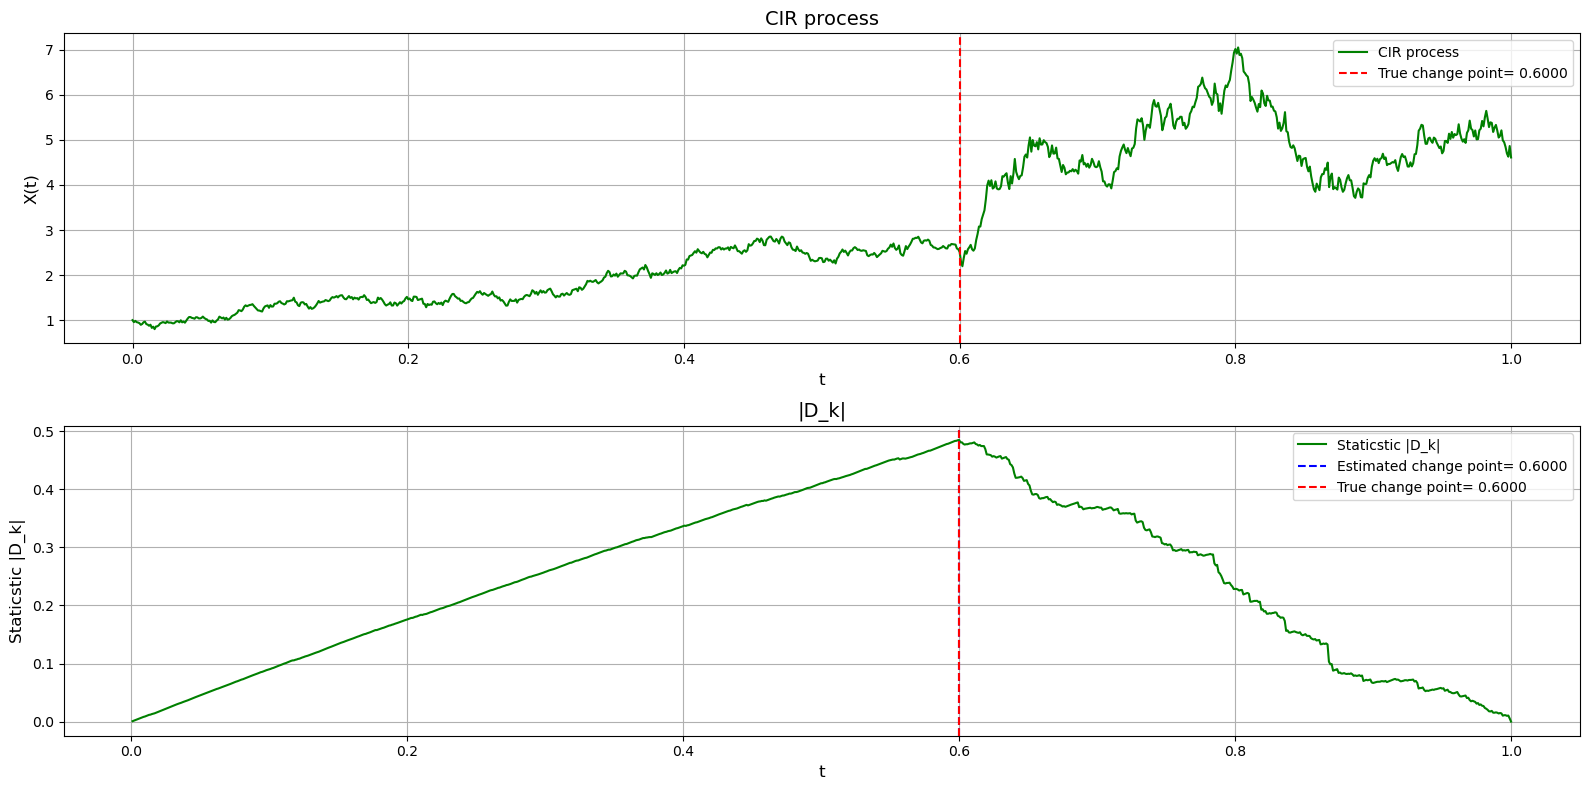

Истинный: t₀ = 0.6
Оценённый: y₀ = 0.6000


In [24]:
import numpy as np
import matplotlib.pyplot as plt

class CIRProcessSimulation:
    def __init__(self, n=1000, T=1.0, tau0=0.6, theta1=1.0, theta2=2.0, X0=1.0):
        self.n = n
        self.T = T
        self.tau0 = tau0
        self.theta1 = theta1
        self.theta2 = theta2
        self.X0 = X0
        self.Δt = self.T / self.n
        self.t = np.linspace(0, self.T, self.n + 1)
        self.X = np.zeros(self.n + 1)
        self.X[0] = self.X0
        self.D_k = None

    def simulate(self):
        ΔW = np.sqrt(self.Δt) * np.random.randn(self.n)
        for i in range(self.n):
            theta = self.theta1 if self.t[i] < self.tau0 else self.theta2
            sqrt_Xi = np.sqrt(max(self.X[i], 0))
            self.X[i+1] = self.X[i] + (6 - 2 * self.X[i]) * self.Δt + theta * sqrt_Xi * ΔW[i]
            self.X[i+1] = max(self.X[i+1], 0)

    def estimate_change_point(self):
        Z = ((self.X[1:] - self.X[:-1]) - (6 - 2 * self.X[:-1]) * self.Δt) / np.sqrt(self.Δt)
        Z_squared = Z**2
        S_k = np.cumsum(Z_squared)
        S_n = S_k[-1]
        k_values = np.arange(1, self.n + 1)
        self.D_k = (S_k / S_n) - (k_values / self.n)
        k0 = np.argmax(np.abs(self.D_k))
        t0_estimate = self.t[k0 + 1]
        return t0_estimate

    def plot_results(self, t0_estimate):
        fig, axs = plt.subplots(2, 1, figsize=(16, 8))

        # Plot process
        axs[0].plot(self.t, self.X, color='green', label='CIR process')
        axs[0].axvline(x=self.tau0, color='red', linestyle='--', label=f'True change point= {tau0:.4f}')
        axs[0].set_xlabel('t', fontsize=12)
        axs[0].set_ylabel('X(t)', fontsize=12)
        axs[0].set_title('CIR process', fontsize=14)
        axs[0].legend()
        axs[0].grid(True)

        # Plot estimation
        axs[1].plot(self.t[1:], np.abs(self.D_k), color='green', label='Staticstic |D_k|')
        axs[1].axvline(x=t0_estimate, color='blue', linestyle='--', label=f'Estimated change point= {t0_estimate:.4f}')
        axs[1].axvline(x=self.tau0, color='red', linestyle='--', label=f'True change point= {tau0:.4f}')
        axs[1].set_xlabel('t', fontsize=12)
        axs[1].set_ylabel('Staticstic |D_k|', fontsize=12)
        axs[1].set_title('|D_k|', fontsize=14)
        axs[1].legend()
        axs[1].grid(True)

        plt.tight_layout()
        plt.show()

tau0 = 0.6
simulation = CIRProcessSimulation()
simulation.simulate()
t0_estimate = simulation.estimate_change_point()

simulation.plot_results(t0_estimate)

print(f"Истинный: t₀ = {simulation.tau0}")
print(f"Оценённый: y₀ = {t0_estimate:.4f}")

# Задачи

In [25]:
import scipy.stats as stats
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
from scipy.stats import norm, ttest_1samp
from matplotlib.patches import Circle

Задача 1. Верификация моментов процесса CIR (Раздел 2.3, 8.1)

Для модели CIR существуют аналитические формулы для расчета моментов любого порядка.
1. На основе формулы (Jafari, 2017) вычислите теоретические значения первого и второго моментов $\mathbb E\{X(t)\}$ и $\mathbb E\{X^2(t)\}$ для параметров $κ$, $θ$, $σ$ (задать самостоятельно).

2. Сгенерируйте $M=1000$ траекторий и вычислите выборочное среднее и дисперсию в момент времени $T$ и сравните их с теоретическими значениями, рассчитанными по формуле (Jafari, 2017).

3. Сделайте выводы.

Теоретические моменты при T=2.0:
  E[X(T)] = 1.009158
  Var[X(T)] = 16.756641

Выборочные оценки по 1000 траекториям:
  E[X(T)] = 1.007902 (ошибка: 1.26e-3)
  Var[X(T)] = 0.021340 (ошибка: 1.67e+1)


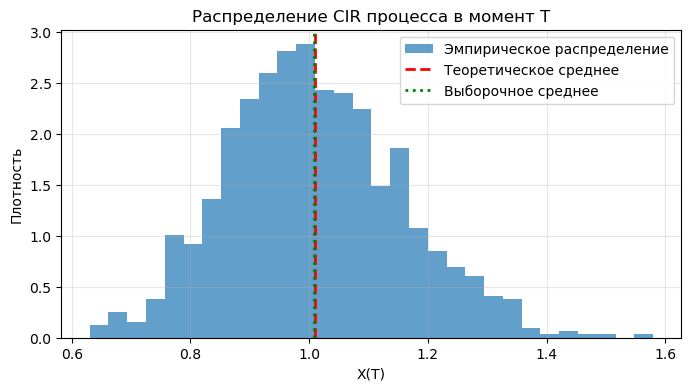

In [26]:
# 1. Параметры модели и теоретические моменты
kappa, theta, sigma, X0, T = 2.0, 1.0, 0.3, 1.5, 2.0
params = [theta, kappa, sigma]

cir = CoxIngersollRossProcess(params, T, Nx=1, Nt=1000, init_state=X0)

# Расчет по формуле Jafari (уже реализовано в классе)
theor_mean = cir.expected_moment(1, T)
theor_2nd_mom = cir.expected_moment(2, T)
theor_var = theor_2nd_mom - theor_mean**2

print(f"Теоретические моменты при T={T}:")
print(f"  E[X(T)] = {theor_mean:.6f}")
print(f"  Var[X(T)] = {theor_var:.6f}")

# 2. Моделирование M траекторий
M = 1000
cir_sim = CoxIngersollRossProcess(params, T, Nx=M, Nt=1000, init_state=X0)
_, x_data = cir_sim.EulerSolution()
x_T = x_data[-1, :]

# Выборочные оценки
sample_mean = np.mean(x_T)
sample_var = np.var(x_T, ddof=1)

print(f"\nВыборочные оценки по {M} траекториям:")
print(f"  E[X(T)] = {sample_mean:.6f} (ошибка: {abs(sample_mean - theor_mean):.2e})")
print(f"  Var[X(T)] = {sample_var:.6f} (ошибка: {abs(sample_var - theor_var):.2e})")

# 3. Визуализация
plt.figure(figsize=(8,4))
plt.hist(x_T, bins=30, density=True, alpha=0.7, label='Эмпирическое распределение')
plt.axvline(theor_mean, color='red', ls='--', lw=2, label=f'Теоретическое среднее')
plt.axvline(sample_mean, color='green', ls=':', lw=2, label=f'Выборочное среднее')
plt.title('Распределение CIR процесса в момент T')
plt.xlabel('X(T)')
plt.ylabel('Плотность')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Задача 2. Свойства модели Блэка-Шоулза-Мертона (Раздел 2.2, 8.4)

Условная плотность процесса BSM является логнормальной.
1. Задайте параметры $θ_1=16\%$ (процентная ставка) и $θ_2=30\%$  (волатильность) и смоделируйте процесс геометрического броуновского движения.
2. Постройте гистограмму значений $\log(X_T​ /X_0)$ и стаститически проверьте её на соответствие нормальному распределению с параметрами
$μ=(θ_1 −θ_2^2/2)T$ и $σ^2 =θ_2^2​ T$. Приведите значение статистики критерия, p-value и пороговое значение.
3. Сделайте выводы.

Теоретические параметры нормального распределения:
  μ = 0.1150
  σ = 0.3000


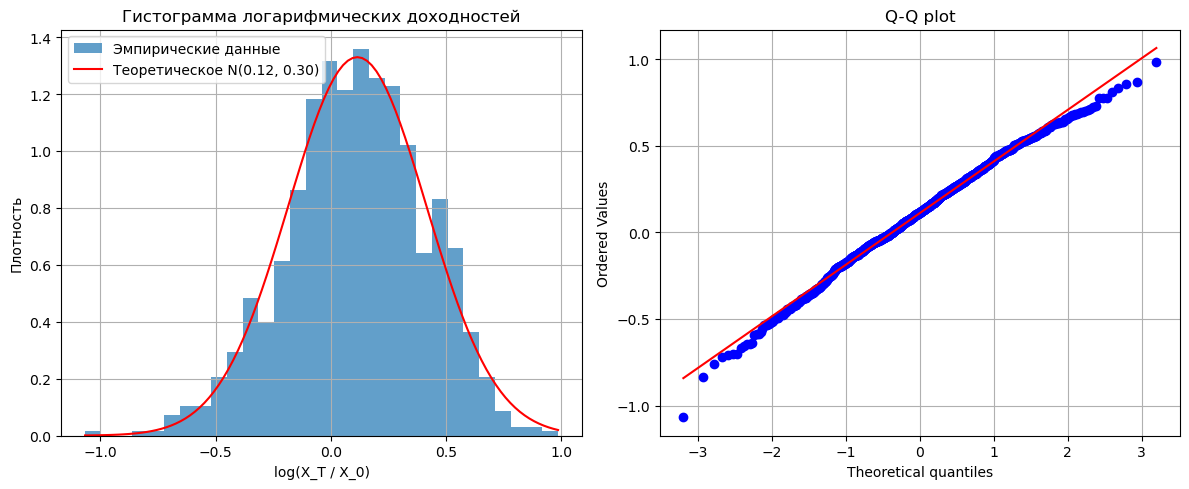


Результаты теста Шапиро-Уилка на нормальность:
  Статистика теста (W): 0.9958
  P-value: 0.0082
  Пороговое значение (alpha): 0.05


In [27]:
# 1. Задаем параметры
theta1 = 0.16
theta2 = 0.30
params = [theta1, theta2]

T = 1.0
Nx = 1
Nt = 1000
M = 1000
x0 = 1.0

# Массив для сбора значений log(X_T / X_0)
log_returns = np.zeros(M)

# Генерация M траекторий
for i in range(M):
    init_state = x0 * np.ones(Nx)
    bsm_process = BlackScholesMertonProcess(params, T, Nx, Nt, init_state)
    t_data, x_data = bsm_process.EulerSolution()
    log_returns[i] = np.log(x_data[-1, 0] / x0)

# 2. Теоретические параметры нормального распределения
mu_theor = (theta1 - theta2**2 / 2) * T
sigma_theor = theta2 * np.sqrt(T)

print(f"Теоретические параметры нормального распределения:")
print(f"  μ = {mu_theor:.4f}")
print(f"  σ = {sigma_theor:.4f}")

# Визуализация
plt.figure(figsize=(12, 5))

# Гистограмма эмпирических данных
plt.subplot(1, 2, 1)
count, bins, _ = plt.hist(log_returns, bins=30, density=True, alpha=0.7, label='Эмпирические данные')

# Теоретическая кривая нормального распределения
x = np.linspace(log_returns.min(), log_returns.max(), 100)
plt.plot(x, norm.pdf(x, mu_theor, sigma_theor), 'r-', label=f'Теоретическое N({mu_theor:.2f}, {sigma_theor:.2f})')
plt.xlabel('log(X_T / X_0)')
plt.ylabel('Плотность')
plt.title('Гистограмма логарифмических доходностей')
plt.legend()
plt.grid(True)

# Q-Q plot для визуальной проверки нормальности
plt.subplot(1, 2, 2)
stats.probplot(log_returns, dist="norm", plot=plt)
plt.title('Q-Q plot')
plt.grid(True)

plt.tight_layout()
plt.show()

# Статистическая проверка на нормальность (тест Шапиро-Уилка)
stat, p_value = stats.shapiro(log_returns)
alpha = 0.05 # Уровень значимости

print(f"\nРезультаты теста Шапиро-Уилка на нормальность:")
print(f"  Статистика теста (W): {stat:.4f}")
print(f"  P-value: {p_value:.4f}")
print(f"  Пороговое значение (alpha): {alpha}")

Задача 3. Модель стохастической волатильности (BSM + CIR)

1. C помощью модели Cox-Ingersoll-Ross (CIR) сгенерируйте траекторию волатильности $\sigma(t)$ с параметрами, обеспечивающими положительность процесса.
2. В класс BlackScholesMertonProcess передайте значение $\sqrt{\sigma(t)}$  из пункта 1.
3. Визуализируйте на двух подобъектах (subplots): верхний график — траектория волатильности (CIR), нижний — цена актива (модифицированный BSM).
4. Сохраните результаты моделирования в файл (*.csv).
5. Сделайте выводы.



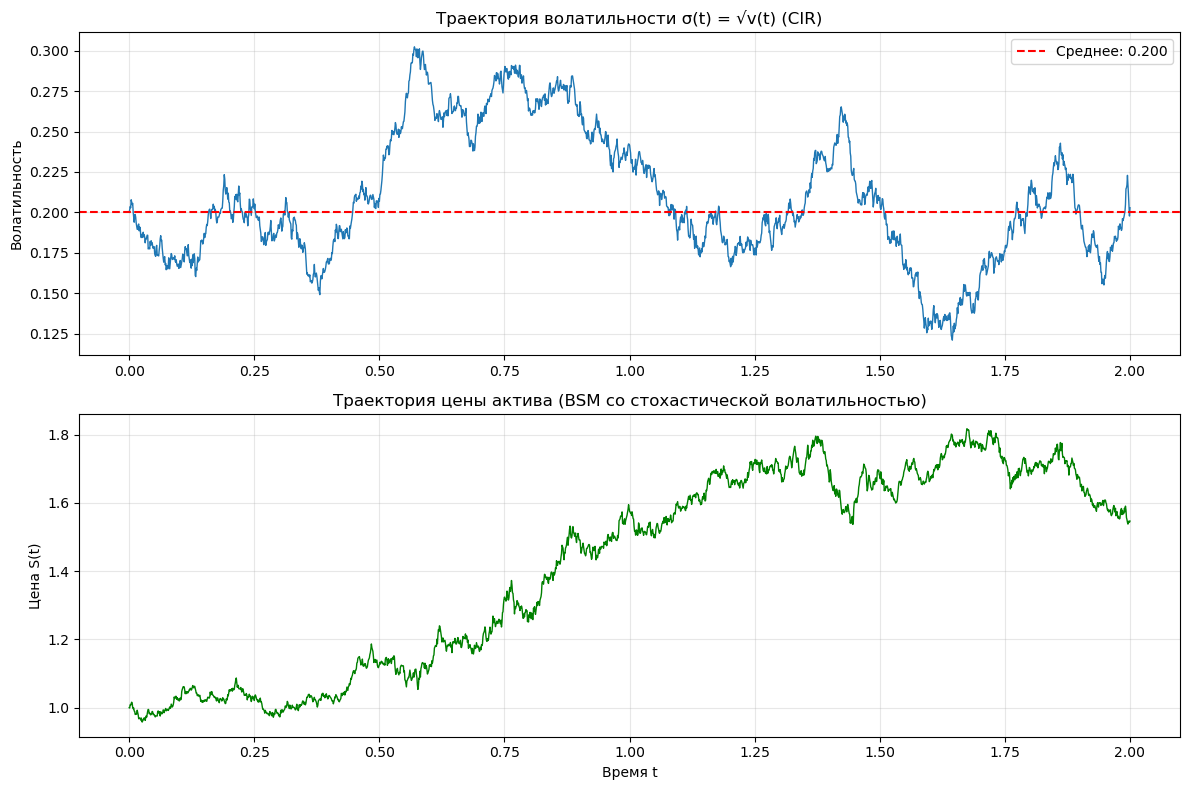

In [28]:
# Параметры моделирования
T, Nt, dt = 2.0, 2000, 2.0 / 2000
mu, S0 = 0.05, 1.0

# Параметры CIR (дисперсия)
kappa, theta, sigma_v, v0 = 2.0, 0.04, 0.2, 0.04

# Генерация CIR и BSM одной траектории
np.random.seed(42)
v, S = np.zeros(Nt + 1), np.zeros(Nt + 1)
v[0], S[0] = v0, S0

for i in range(1, Nt + 1):
    sqrt_v = np.sqrt(max(v[i-1], 0))
    dW = np.random.normal()
    v[i] = max(v[i-1] + kappa * (theta - v[i-1]) * dt + sigma_v * sqrt_v * np.sqrt(dt) * dW, 1e-8)
    S[i] = max(S[i-1] + mu * S[i-1] * dt + np.sqrt(v[i-1]) * S[i-1] * np.sqrt(dt) * np.random.normal(), 0)

# Визуализация
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
t = np.linspace(0, T, Nt + 1)

ax1.plot(t, np.sqrt(v), lw=1)
ax1.axhline(y=np.sqrt(theta), color='r', ls='--', label=f'Среднее: {np.sqrt(theta):.3f}')
ax1.set(ylabel='Волатильность', title='Траектория волатильности σ(t) = √v(t) (CIR)')
ax1.legend(), ax1.grid(alpha=0.3)

ax2.plot(t, S, 'g', lw=1)
ax2.set(xlabel='Время t', ylabel='Цена S(t)', title='Траектория цены актива (BSM со стохастической волатильностью)')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Сохранение и выводы
np.savetxt('stochastic_volatility_simulation.csv', 
           np.column_stack((t, np.sqrt(v), S)), 
           delimiter=',', header='Time,Volatility_CIR,Asset_Price_BSM', comments='', fmt='%.6f')

Задача 4. Смена режима для траектории (Regime Switching)

1. Сгенерируйте траекторию процесса Ornstein-Uhlenbeck (OU) на интервале $t∈[0,0.5]$ с параметрами, обеспечивающими возврат к среднему $\mu=1.2$.
2. В момент времени $\tau_0=0.5$ (точка смены режима) переключите динамику системы на модель Ait-Sahalia или Black-Scholes-Merton, используя конечное значение OU-процесса как начальное состояние для следующего этапа $t\in [0.5; 1.0]$.
3. Соедините две траектории в одну и постройте график, отметив вертикальной линией момент смены режима.
4. Стастический оцените точку смены тенденции и сравните ее c $\tau_0$. Постройте график статистики и нанесите две вертикальные линии для $\tau_0$ и ее оценки.
5. Сохраните результаты моделирования в файл (*.csv).
6. Сделайте выводы. Объясните, как меняются свойства траектории.

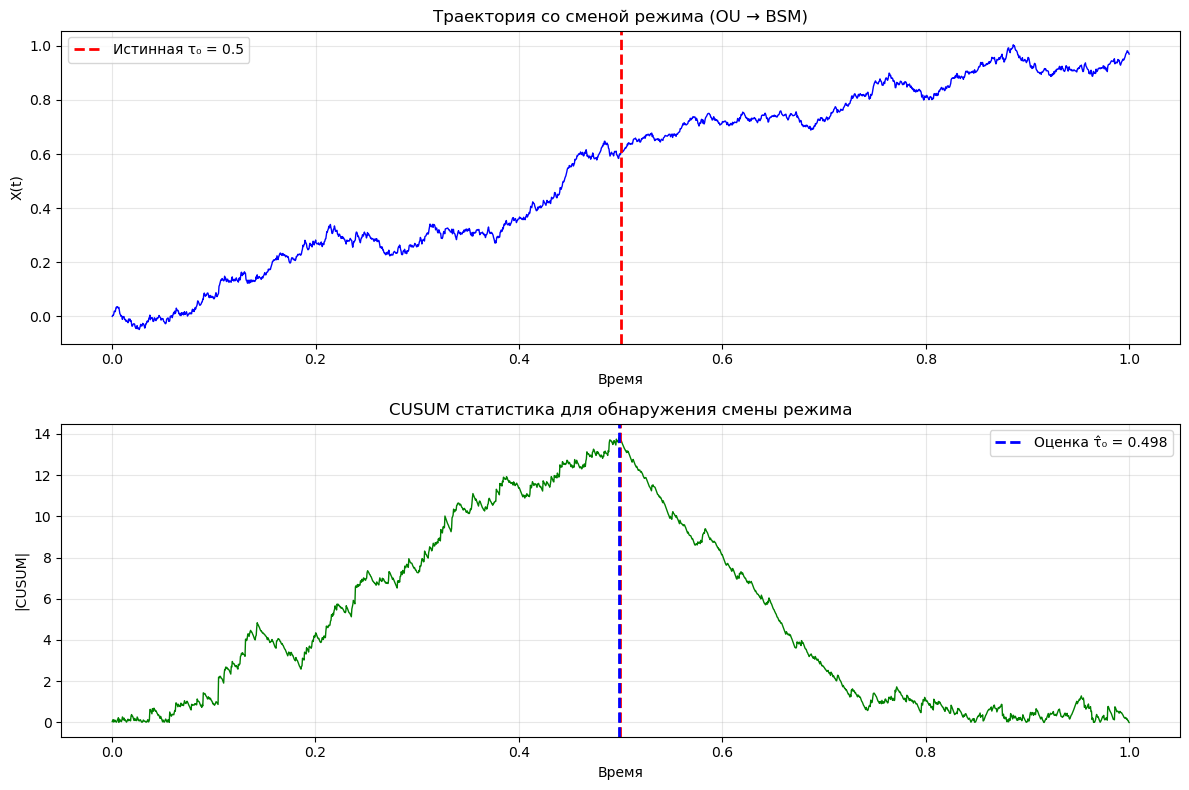

Истинная точка смены: 0.5
Оцененная точка смены: 0.4985
Погрешность: 0.0015


In [29]:
# Параметры
T1, T2 = 0.5, 0.5
Nt = 1000
dt1 = dt2 = T1 / Nt
tau0 = 0.5
np.random.seed(42)

# 1. OU процесс (t ∈ [0, 0.5])
theta, mu, sigma = 1.0, 1.2, 0.3
t1 = np.linspace(0, T1, Nt + 1)
x1 = np.zeros(Nt + 1)
x1[0] = 0.0

for i in range(1, Nt + 1):
    dW = np.random.normal(0, np.sqrt(dt1))
    x1[i] = x1[i-1] + theta * (mu - x1[i-1]) * dt1 + sigma * dW

# 2. BSM процесс (t ∈ [0.5, 1.0])
mu_bsm, sigma_bsm = 0.05, 0.3
t2 = np.linspace(T1, T1 + T2, Nt + 1)
x2 = np.zeros(Nt + 1)
x2[0] = x1[-1]

for i in range(1, Nt + 1):
    dW = np.random.normal(0, np.sqrt(dt2))
    x2[i] = x2[i-1] + mu_bsm * x2[i-1] * dt2 + sigma_bsm * x2[i-1] * dW

# 3. Объединение
t_combined = np.concatenate([t1, t2[1:]])
x_combined = np.concatenate([x1, x2[1:]])

# 4. Оценка точки смены (CUSUM по квадратам приращений)
dx = np.diff(x_combined)
dt = t_combined[1] - t_combined[0]
sq_inc = (dx / np.sqrt(dt))**2
cusum = np.cumsum(sq_inc - np.mean(sq_inc))
t_estimated = t_combined[np.argmax(np.abs(cusum)) + 1]

# 5. Визуализация
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

ax1.plot(t_combined, x_combined, 'b-', lw=1)
ax1.axvline(tau0, color='r', ls='--', lw=2, label=f'Истинная τ₀ = {tau0}')
ax1.set_xlabel('Время'); ax1.set_ylabel('X(t)')
ax1.set_title('Траектория со сменой режима (OU → BSM)')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(t_combined[1:], np.abs(cusum), 'g-', lw=1)
ax2.axvline(tau0, color='r', ls='--', lw=2)
ax2.axvline(t_estimated, color='b', ls='--', lw=2, 
            label=f'Оценка τ̂₀ = {t_estimated:.3f}')
ax2.set_xlabel('Время'); ax2.set_ylabel('|CUSUM|')
ax2.set_title('CUSUM статистика для обнаружения смены режима')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 6. Сохранение
pd.DataFrame({'time': t_combined, 'X': x_combined}).to_csv(
    'regime_switching_trajectory.csv', index=False)

# 7. Выводы
print(f"Истинная точка смены: {tau0}")
print(f"Оцененная точка смены: {t_estimated:.4f}")
print(f"Погрешность: {abs(t_estimated - tau0):.4f}")

Задача 5. Сравнение моделей с возвратом к среднему и их калибровка

1. Рассмотрите следующие модели

Ornstein–Uhlenbeck (OU):  
  $$
  dX_t = \kappa (\theta - X_t) dt + \sigma dW_t
  $$  

Cox–Ingersoll–Ross (CIR):  
  $$
  dX_t = \kappa (\theta - X_t) dt + \sigma \sqrt{X_t} dW_t
  $$  

Модифицированный CIR (с добавлением квадратичного члена в волатильности):  
  $$
  dX_t = \kappa (\theta - X_t) dt + \sigma X_t^{3/2} dW_t
  $$  
  
Модель Ait–Sahalia с нелинейным дрейфом:  
  $$
  dX_t = (\alpha_{-1}X_t^{-1} + \alpha_0 + \alpha_1 X_t + \alpha_2 X_t^2) dt + \sigma X_t^{\rho} dW_t
  $$  

Диффузия Якоби (ограниченная на интервале):  
  $$
  dX_t = \kappa (\theta - X_t) dt + \sigma \sqrt{X_t(1 - X_t)} dW_t, \quad X_t \in (0,1)
  $$  

Для каждой модели самостоятельно укажите:  
  - область значений процесса;  
  - условия на параметры, обеспечивающие строгую положительность (если требуется);  
  - выражение для стационарной плотности распределения (если она существует).  


2. Сгенерируйте по 500 траекторий для каждой из пяти моделей с использованием следующих зачений параметров:  
  $$
  \kappa = 2.0,\quad \theta = 1.0,\quad X_0 = 1.5,\quad T = 2.0,\quad \Delta t = 0.001
  $$  
  Для волатильности используйте:  
  $$
  \sigma = 0.3 \quad \text{(для моделей, где это подходит)}.
  $$  
  Для модели Ait–Sahalia используйте:  
  $$
  \alpha_{-1}=0.5,\ \alpha_0=0.1,\ \alpha_1=-2,\ \alpha_2=0,\ \rho=1.5.
  $$  

   

3. Для каждой модели оцените:  
  - выборочное среднее и дисперсию в момент $T$;  
  - выборочный коэффициент возврата к среднему (оцените скорость сходимости к $\theta$;  
  - вероятности выхода процессов за заданные пороги $X_t < 0.5$ и $X_t > 2.0$ на промежутке $[0, T]$.  

4. Постройте на одном графике 10 траекторий каждой модели (разными цветами) и отдельно график выборочных средних по времени для всех моделей.  

5. Сделайте выводы.

              mean_T   var_T  kappa_est  P(X<0.5)  P(X>2.0)
OU            0.9933  0.0213     1.9556     0.006     0.000
CIR           1.0134  0.0250     2.0658     0.000     0.000
Modified CIR  1.0102  0.0269     2.4948     0.000     0.038
Ait-Sahalia   0.5309  0.0017     0.3707     0.898     0.002
Jacobi        1.0091  0.0000     0.0000     0.000     0.000


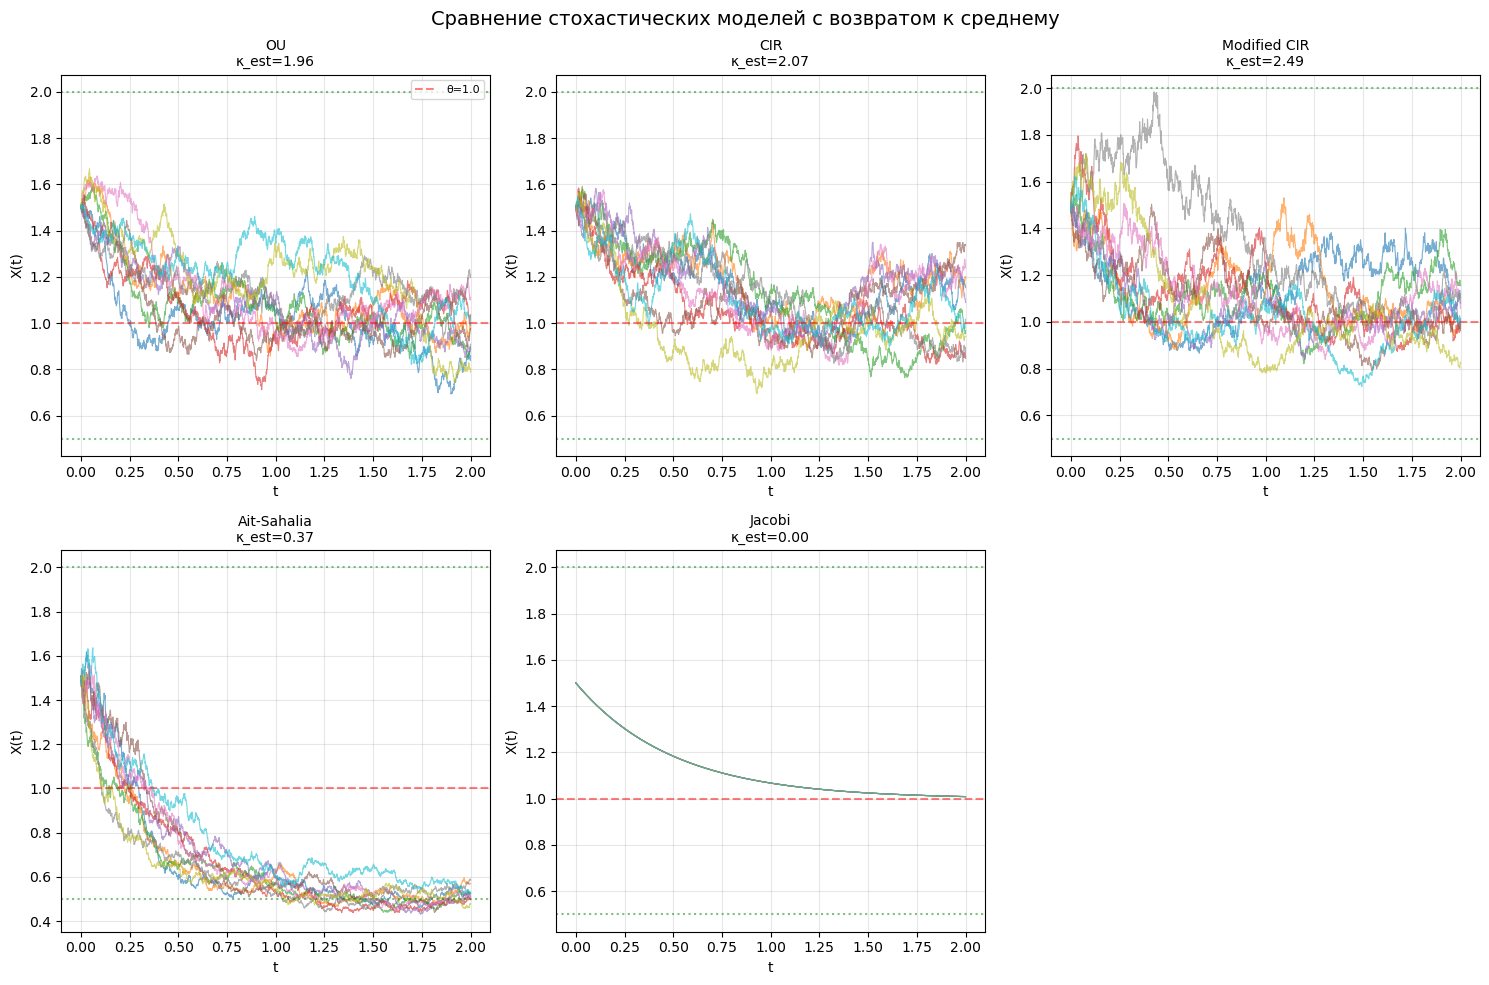

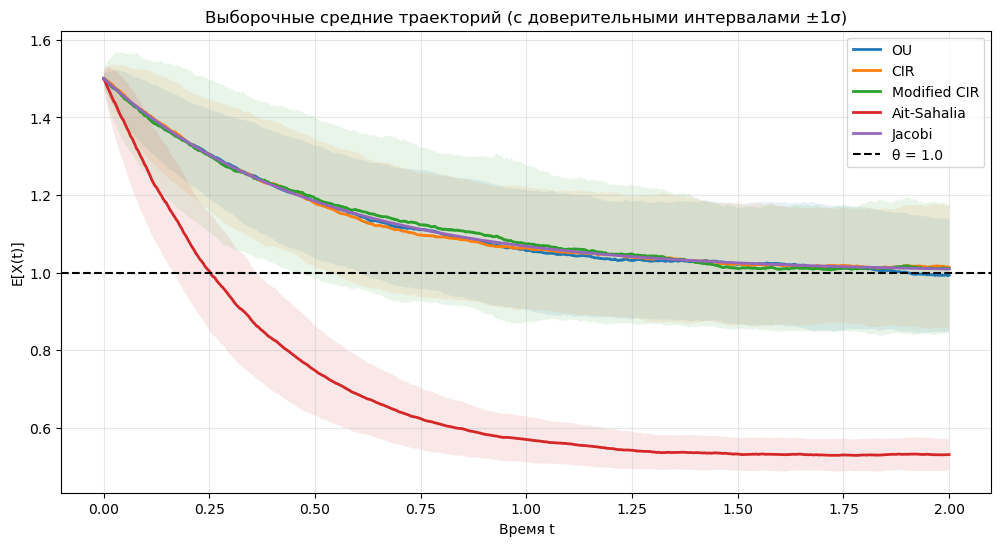

In [30]:
#  1. ЧИСЛЕННОЕ МОДЕЛИРОВАНИЕ 
class StochasticProcess:
    def __init__(self, drift, diffusion, T, dt, x0):
        self.drift = drift
        self.diffusion = diffusion
        self.T = T
        self.dt = dt
        self.Nt = int(T / dt)
        self.x0 = x0
        
    def simulate(self, n_paths):
        paths = np.zeros((n_paths, self.Nt + 1))
        paths[:, 0] = self.x0
        
        for i in range(self.Nt):
            dW = np.random.normal(0, np.sqrt(self.dt), n_paths)
            x = paths[:, i]
            # Коррекция для положительных процессов
            x = np.maximum(x, 1e-10) if 'positive' in self.__class__.__name__.lower() else x
            paths[:, i+1] = x + self.drift(x) * self.dt + self.diffusion(x) * dW
            
        return paths

# Параметры моделирования
kappa, theta, sigma = 2.0, 1.0, 0.3
T, dt, x0, n_paths = 2.0, 0.001, 1.5, 500

# Определение моделей
models = {
    'OU': StochasticProcess(
        lambda x: kappa * (theta - x),
        lambda x: sigma,
        T, dt, x0
    ),
    'CIR': StochasticProcess(
        lambda x: kappa * (theta - x),
        lambda x: sigma * np.sqrt(np.maximum(x, 0)),
        T, dt, x0
    ),
    'Modified CIR': StochasticProcess(
        lambda x: kappa * (theta - x),
        lambda x: sigma * np.power(np.maximum(x, 1e-10), 1.5),
        T, dt, x0
    ),
    'Ait-Sahalia': StochasticProcess(
        lambda x: 0.5/x + 0.1 - 2*x,
        lambda x: sigma * np.power(np.maximum(x, 1e-10), 1.5),
        T, dt, x0
    ),
    'Jacobi': StochasticProcess(
        lambda x: kappa * (theta - x),
        lambda x: sigma * np.sqrt(np.maximum(x * (1 - x), 0)),
        T, dt, x0
    )
}

#  2. АНАЛИЗ РЕЗУЛЬТАТОВ 
results = {}
paths_data = {}

for name, model in models.items():
    # Генерация траекторий
    paths = model.simulate(n_paths)
    paths_data[name] = paths
    
    # Конечные значения
    final_vals = paths[:, -1]
    t_axis = np.linspace(0, T, model.Nt + 1)
    
    # Оценка скорости возврата к среднему (через автокорреляцию)
    autocorr = []
    for i in range(n_paths):
        acf = np.corrcoef(paths[i, :-1], paths[i, 1:])[0, 1]
        autocorr.append(acf if not np.isnan(acf) else 0)
    mean_autocorr = np.mean(autocorr)
    estimated_kappa = (1 - mean_autocorr) / dt if mean_autocorr < 1 else 0
    
    # Статистики
    results[name] = {
        'mean_T': np.mean(final_vals),
        'var_T': np.var(final_vals, ddof=1),
        'kappa_est': estimated_kappa,
        'P(X<0.5)': np.mean(np.any(paths < 0.5, axis=1)),
        'P(X>2.0)': np.mean(np.any(paths > 2.0, axis=1))
    }

# Вывод таблицы
df_results = pd.DataFrame(results).T.round(4)
print(df_results.to_string())

#  3. ВИЗУАЛИЗАЦИЯ 
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
t_axis = np.linspace(0, T, model.Nt + 1)

for idx, (name, paths) in enumerate(paths_data.items()):
    ax = axes[idx]
    sample_idx = np.random.choice(n_paths, min(10, n_paths), replace=False)
    for i in sample_idx:
        ax.plot(t_axis, paths[i], alpha=0.6, lw=0.8)
    ax.set_title(f'{name}\nκ_est={results[name]["kappa_est"]:.2f}', fontsize=10)
    ax.set_xlabel('t'); ax.set_ylabel('X(t)')
    ax.axhline(theta, color='r', ls='--', alpha=0.5, label=f'θ={theta}')
    ax.axhline(0.5, color='g', ls=':', alpha=0.5)
    ax.axhline(2.0, color='g', ls=':', alpha=0.5)
    ax.grid(True, alpha=0.3)
    if idx == 0: ax.legend(fontsize=8)

if len(models) < 6:
    fig.delaxes(axes[-1])

plt.suptitle('Сравнение стохастических моделей с возвратом к среднему', fontsize=14)
plt.tight_layout()
plt.show()

# График выборочных средних
plt.figure(figsize=(12, 6))
for name, paths in paths_data.items():
    mean_path = np.mean(paths, axis=0)
    std_path = np.std(paths, axis=0)
    plt.plot(t_axis, mean_path, label=name, lw=2)
    plt.fill_between(t_axis, mean_path - std_path, mean_path + std_path, alpha=0.1)

plt.axhline(theta, color='black', ls='--', label=f'θ = {theta}')
plt.xlabel('Время t'); plt.ylabel('E[X(t)]')
plt.title('Выборочные средние траекторий (с доверительными интервалами ±1σ)')
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

#  5. СОХРАНЕНИЕ РЕЗУЛЬТАТОВ
# Сохраняем результаты для каждой модели
for name, paths in paths_data.items():
    df = pd.DataFrame(paths.T)
    df.insert(0, 'time', t_axis)
    df.columns = ['time'] + [f'path_{i}' for i in range(n_paths)]
    df.to_csv(f'{name.replace(" ", "_")}_trajectories.csv', index=False)

# Сохраняем сводную таблицу
df_results.to_csv('model_comparison_summary.csv')

Задача 6.

1. Смоделируйте процесс
$$
dX_t = \mu(X^1_t ,X^2_t )dt+\sigma(X^1_t ,X^2_t )dW_t,\  
Θ=\{x \in \mathbf{R}^2 | x^2_1 + x^2_2=1\}.
$$

$$
\mu(x_1 ,x_2) =
\begin{cases}
(1,1)^\top &,\quad x^2_1 + x^2_2 > 1, \\
(-x_1, x_2)^\top &,\quad x^2_1 + x^2_2 \leq 1,
\end{cases}
$$

$$
\sigma(x_1,x_2) =\frac{1}{1+ x^2_1+ x^2_2}
\begin{pmatrix}
x_1 & 0\\
x_2 & 0
\end{pmatrix}
$$

2. Постройте график траектории.

3. Сделайте выводы.

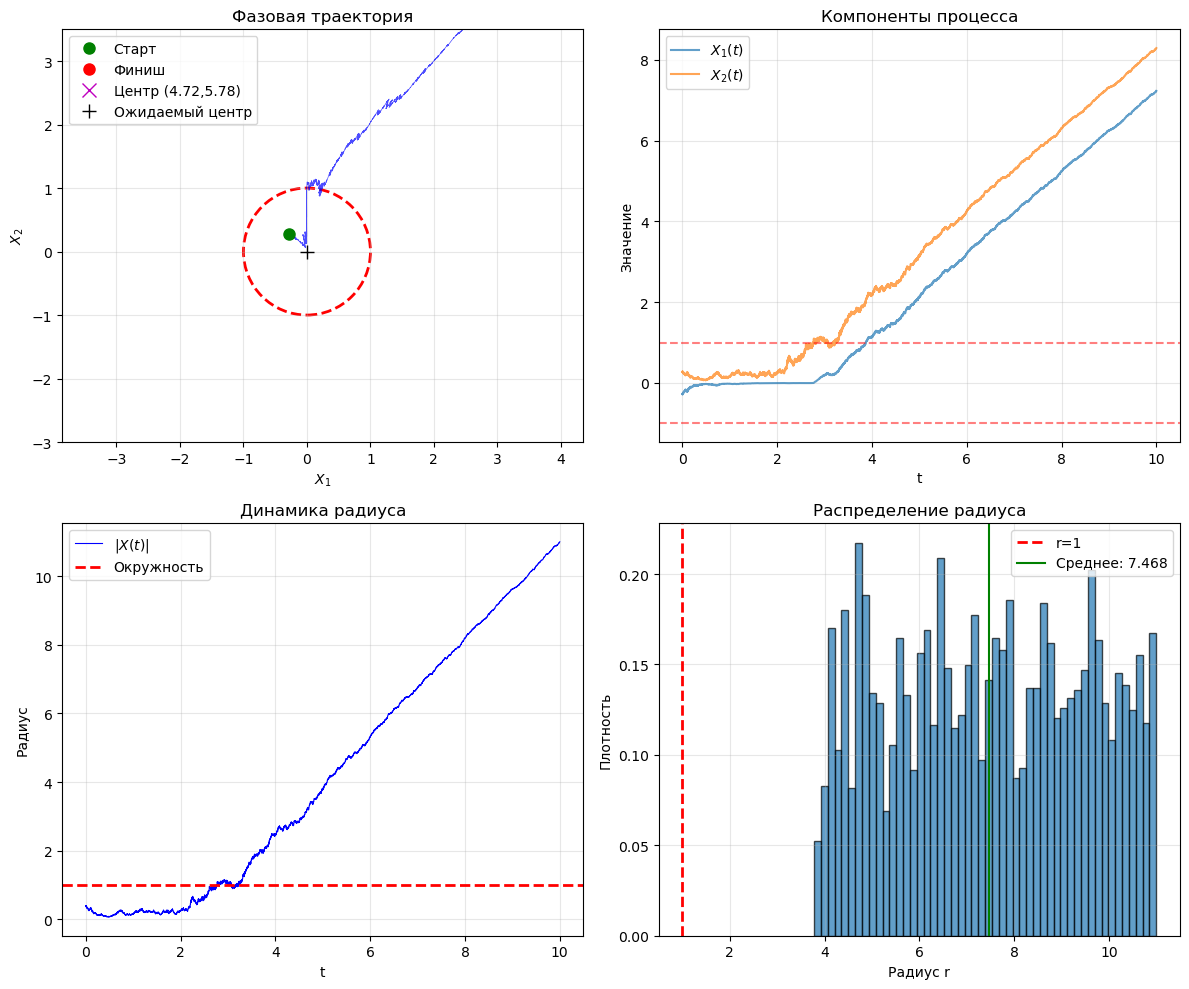

In [54]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

# 1. ОПРЕДЕЛЕНИЕ ПРОЦЕССА
class SphereAttractorProcess:
    def __init__(self, T, dt, x0):
        self.T, self.dt, self.Nt = T, dt, int(T/dt)
        self.x0 = np.array(x0)
    
    def drift(self, x):
        return np.array([1.0, 1.0]) if x[0]**2+x[1]**2 > 1 else np.array([-x[0], x[1]])
    
    def diffusion(self, x):
        scale = 1.0/(1.0 + x[0]**2 + x[1]**2)
        return scale * np.array([[x[0], 0], [x[1], 0]])
    
    def simulate(self):
        t = np.linspace(0, self.T, self.Nt+1)
        X = np.zeros((self.Nt+1, 2))
        X[0] = self.x0
        for i in range(self.Nt):
            dW = np.random.normal(0, np.sqrt(self.dt), size=2)
            X[i+1] = X[i] + self.drift(X[i])*self.dt + self.diffusion(X[i]) @ dW
        return t, X

# 2. МОДЕЛИРОВАНИЕ (случайная начальная точка)
T, dt = 10.0, 0.001
#np.random.seed(42)
x0 = np.random.uniform(-2, 2, 2)
process = SphereAttractorProcess(T, dt, x0)
t, X = process.simulate()

r = np.sqrt(X[:,0]**2 + X[:,1]**2)
center = np.mean(X[t > T/2], axis=0)

# 3. ВИЗУАЛИЗАЦИЯ
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Фазовая траектория
ax = axes[0,0]
ax.plot(X[:,0], X[:,1], 'b-', lw=0.5, alpha=0.7)
ax.add_patch(Circle((0,0), 1, fill=False, color='r', lw=2, ls='--'))
ax.plot(x0[0], x0[1], 'go', ms=8, label='Старт')
ax.plot(X[-1,0], X[-1,1], 'ro', ms=8, label='Финиш')
ax.plot(center[0], center[1], 'mx', ms=10, label=f'Центр ({center[0]:.2f},{center[1]:.2f})')
ax.plot(0,0, 'k+', ms=10, label='Ожидаемый центр')
ax.set_xlabel('$X_1$'); ax.set_ylabel('$X_2$')
ax.set_title('Фазовая траектория'); ax.legend(); ax.grid(True, alpha=0.3)
ax.axis('equal'); ax.set_xlim(-3,3.5); ax.set_ylim(-3,3.5)

# Компоненты
ax = axes[0,1]
ax.plot(t, X[:,0], label='$X_1(t)$', alpha=0.7)
ax.plot(t, X[:,1], label='$X_2(t)$', alpha=0.7)
ax.axhline(1, c='r', ls='--', alpha=0.5)
ax.axhline(-1, c='r', ls='--', alpha=0.5)
ax.set_xlabel('t'); ax.set_ylabel('Значение')
ax.set_title('Компоненты процесса'); ax.legend(); ax.grid(True, alpha=0.3)

# Эволюция радиуса
ax = axes[1,0]
ax.plot(t, r, 'b-', lw=0.8, label='$|X(t)|$')
ax.axhline(1, c='r', ls='--', lw=2, label='Окружность')
ax.set_xlabel('t'); ax.set_ylabel('Радиус')
ax.set_title('Динамика радиуса'); ax.legend(); ax.grid(True, alpha=0.3)

# Гистограмма радиуса
ax = axes[1,1]
r_stat = r[t > T/2]
ax.hist(r_stat, bins=50, density=True, alpha=0.7, edgecolor='black')
ax.axvline(1, c='r', ls='--', lw=2, label='r=1')
ax.axvline(np.mean(r_stat), c='g', ls='-', label=f'Среднее: {np.mean(r_stat):.3f}')
ax.set_xlabel('Радиус r'); ax.set_ylabel('Плотность')
ax.set_title('Распределение радиуса'); ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()